# Topic 6 — Wrapper Methods
**Covers:** Recursive Feature Elimination (RFE) · RFECV (auto-selecting the feature count) ·
Forward/backward selection · Computational cost · Model dependency · Final performance
comparison across all selection strategies · Hybrid filter-then-wrapper pipeline

**Dataset:** `data/raw/feature_selection_data.csv` — same PrepEdge dropout-risk data as
Topic 5, so you can directly compare what filter methods flagged versus what a real model,
actually trained repeatedly, chooses to keep.

---
## Explanation

Last time (filter methods), we sorted toys with QUICK rules, without really playing with them.

Wrapper methods are different: imagine you actually build a small LEGO tower with different
sets of pieces, and see which combination makes the TALLEST, most stable tower — by literally
testing it each time, not just eyeballing the pieces.

- **Recursive Feature Elimination (RFE)** = build the tower with ALL your pieces, find the
  piece that's helping the LEAST (barely holding anything up), remove it, rebuild, and repeat —
  each round, you throw away the least useful piece, based on an ACTUAL test.
- **RFECV** = the same idea, but you also let the helper figure out the BEST number of pieces
  to keep by itself, by testing several tower sizes and picking whichever one actually works
  best — instead of you guessing "keep exactly 4 pieces" in advance.
- **Forward selection** = the opposite: start with ZERO pieces, and add ONE piece at a time —
  always the piece that helps the tower the most right now — until adding more doesn't help.
- **Backward selection** = start with ALL pieces (like RFE) and remove the least helpful one,
  one at a time, until removing more starts hurting the tower.
- **Computational cost** = building and testing the tower over and over (with different piece
  combos) takes a lot MORE time and effort than just eyeballing each piece once (filter
  methods). More thorough, but slower and more expensive.
- **Model dependency** = the "best" tower depends on WHO'S judging it — a judge who only cares
  about height might pick different pieces than a judge who cares about stability. Similarly,
  wrapper methods pick different features depending on which MODEL (linear regression, random
  forest, etc.) is doing the choosing.

## 1. WHY — Why go beyond filter methods?

Filter methods (Topic 5) score each feature *independently*, using simple statistics. They
never actually test "does MY model get better with this feature, combined with these OTHERS?"
Wrapper methods answer exactly that question — by repeatedly training a real model on
different feature subsets and keeping whichever subset performs best.

The tradeoff: wrapper methods are **far more computationally expensive**, since they train a
model many times over, and their answer is **tied to the specific model** used to wrap around.

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("../data/raw/feature_selection_data.csv")

work = df.copy()
work["attendance_mode_enc"] = LabelEncoder().fit_transform(work["attendance_mode"])
work["random_categorical_noise_enc"] = LabelEncoder().fit_transform(work["random_categorical_noise"])

feature_cols = ["attendance_pct", "study_hours", "prev_score", "fee_delay_days",
                "attendance_mode_enc", "attendance_pct_copy", "study_minutes_scaled",
                "random_numeric_noise", "random_categorical_noise_enc"]

X = work[feature_cols]
y = work["at_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

# Scale for a fair, stable Logistic Regression fit
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

X_train_scaled.head()

,attendance_pct,study_hours,prev_score,fee_delay_days,attendance_mode_enc,attendance_pct_copy,study_minutes_scaled,random_numeric_noise,random_categorical_noise_enc
891,-0.529482,0.828406,-1.547192,-0.872934,-0.134535,-0.530133,0.830733,0.846824,1.403534
106,-0.333979,-0.289303,-0.178953,-0.658043,-0.134535,-0.307138,-0.341741,-0.657377,0.487301
733,0.272756,-1.646522,0.726400,2.442524,-0.134535,0.301031,-1.679906,0.159474,-0.428933
243,-1.176667,0.069960,-1.914779,4.345843,-0.134535,-1.226149,0.068159,0.577861,-1.345167
161,0.191858,1.067915,-0.485275,-0.944565,-0.134535,0.179397,1.078936,0.119628,-1.345167


## 2. Recursive Feature Elimination (RFE) — WHY / WHAT / HOW

**Manual walk-through of the logic (RFE with a toy example of 4 features):**
```
Round 1: fit model on [A, B, C, D] -> rank importances -> D is weakest -> drop D
Round 2: fit model on [A, B, C]    -> rank importances -> C is weakest -> drop C
Round 3: fit model on [A, B]       -> stop (target: keep 2 features)
Final selected: [A, B]
```
Each round, the model is RE-TRAINED from scratch on the remaining features — that repeated
re-training is exactly what makes RFE a "wrapper" method, and exactly why it costs more than a
filter method's single pass.

In [2]:
from sklearn.feature_selection import RFE

model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=4)
rfe.fit(X_train_scaled, y_train)

ranking = pd.DataFrame({
    "feature": feature_cols,
    "selected": rfe.support_,
    "rank": rfe.ranking_,   # 1 = selected; higher = eliminated earlier
}).sort_values("rank")
ranking

,feature,selected,rank
0,attendance_pct,True,1
2,prev_score,True,1
3,fee_delay_days,True,1
5,attendance_pct_copy,True,1
1,study_hours,False,2
7,random_numeric_noise,False,3
4,attendance_mode_enc,False,4
8,random_categorical_noise_enc,False,5
6,study_minutes_scaled,False,6


Notice which features RFE keeps: the genuinely predictive ones (`attendance_pct`,
`study_hours`, `prev_score`, `fee_delay_days`) should rank at the top, while the noise columns
and redundant duplicates rank lower — RFE arrives at a similar conclusion to Topic 5's filter
methods, but by actually testing combinations with a real model, rather than scoring columns
independently.

## 3. RFECV — letting the model choose HOW MANY features to keep

**Why:** plain RFE requires you to specify `n_features_to_select` up front — but how would you
know the right number in advance? **RFECV** wraps RFE in cross-validation: it tries every
possible feature-count, measures validated performance at each size, and automatically picks
the size that performs best — removing the guesswork.

In [3]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(estimator=LogisticRegression(max_iter=1000), min_features_to_select=1,
              cv=5, scoring="roc_auc")
rfecv.fit(X_train_scaled, y_train)

print(f"RFECV automatically chose {rfecv.n_features_} features (out of {len(feature_cols)} candidates)")
print("Selected features:", list(np.array(feature_cols)[rfecv.support_]))

RFECV automatically chose 3 features (out of 9 candidates)
Selected features: [np.str_('attendance_pct'), np.str_('prev_score'), np.str_('attendance_pct_copy')]


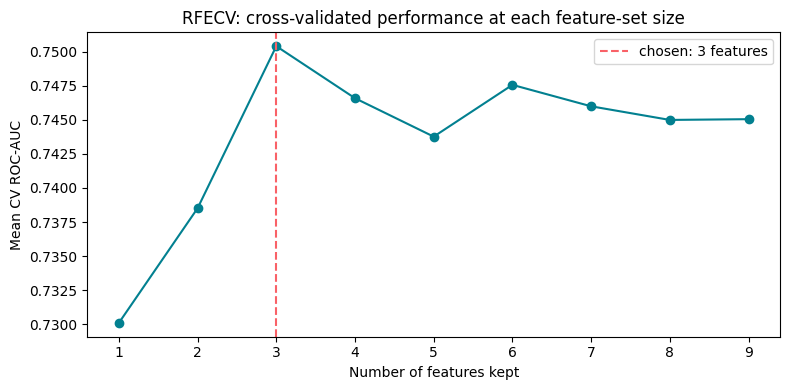

In [4]:
import matplotlib.pyplot as plt

cv_scores = rfecv.cv_results_["mean_test_score"]
n_features_range = range(1, len(cv_scores) + 1)

plt.figure(figsize=(8, 4))
plt.plot(n_features_range, cv_scores, marker="o", color="#028090")
plt.axvline(rfecv.n_features_, color="#F96167", linestyle="--", label=f"chosen: {rfecv.n_features_} features")
plt.xlabel("Number of features kept")
plt.ylabel("Mean CV ROC-AUC")
plt.title("RFECV: cross-validated performance at each feature-set size")
plt.legend()
plt.tight_layout()
plt.show()

**How to read this:** performance typically climbs sharply as the first few genuinely useful
features are added, then flattens (or even dips slightly) once noise/redundant columns start
being included — RFECV picks the peak (or the simplest model within a small tolerance of the
peak), giving you a principled answer to "how many features are actually worth keeping?"

## 4. Forward selection — WHY / WHAT / HOW

**Manual walk-through:**
```
Round 1: try each single feature alone -> best single feature = attendance_pct -> keep it
Round 2: try attendance_pct + each remaining feature -> best pair adds study_hours -> keep it
Round 3: try [attendance_pct, study_hours] + each remaining -> best triple adds prev_score
... continue until adding any more feature stops improving validation performance
```
Forward selection is the mirror image of RFE: it BUILDS UP from nothing, instead of trimming
down from everything.

In [5]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000),
    n_features_to_select=4,
    direction="forward",
    scoring="roc_auc",
    cv=5,
)
sfs_forward.fit(X_train_scaled, y_train)
print("Forward-selected features:", list(np.array(feature_cols)[sfs_forward.get_support()]))

Forward-selected features: [np.str_('attendance_pct'), np.str_('study_hours'), np.str_('prev_score'), np.str_('fee_delay_days')]


## 5. Backward selection — WHY / WHAT / HOW

The mirror of forward selection: start with everything, and remove the single least-useful
feature at each round, based on actual cross-validated model performance, until reaching the
target feature count.

In [6]:
sfs_backward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000),
    n_features_to_select=4,
    direction="backward",
    scoring="roc_auc",
    cv=5,
)
sfs_backward.fit(X_train_scaled, y_train)
print("Backward-selected features:", list(np.array(feature_cols)[sfs_backward.get_support()]))

Backward-selected features: [np.str_('study_hours'), np.str_('prev_score'), np.str_('fee_delay_days'), np.str_('attendance_pct_copy')]


## 6. Computational cost — measuring it directly

Let's actually TIME all four wrapper approaches against a filter method (ANOVA F-test) doing
the equivalent job, on this same (small) dataset — the gap only grows on bigger data /
more features.

In [7]:
from sklearn.feature_selection import f_classif, SelectKBest

timings = {}

start = time.time()
SelectKBest(f_classif, k=4).fit(X_train_scaled, y_train)
timings["Filter (ANOVA F-test)"] = time.time() - start

start = time.time()
RFE(LogisticRegression(max_iter=1000), n_features_to_select=4).fit(X_train_scaled, y_train)
timings["Wrapper: RFE (fixed k=4)"] = time.time() - start

start = time.time()
RFECV(LogisticRegression(max_iter=1000), cv=5, scoring="roc_auc").fit(X_train_scaled, y_train)
timings["Wrapper: RFECV (auto k)"] = time.time() - start

start = time.time()
SequentialFeatureSelector(LogisticRegression(max_iter=1000), n_features_to_select=4,
                           direction="forward", cv=5).fit(X_train_scaled, y_train)
timings["Wrapper: Forward selection"] = time.time() - start

start = time.time()
SequentialFeatureSelector(LogisticRegression(max_iter=1000), n_features_to_select=4,
                           direction="backward", cv=5).fit(X_train_scaled, y_train)
timings["Wrapper: Backward selection"] = time.time() - start

for method, seconds in timings.items():
    print(f"{method:32s} {seconds:.3f} sec")

Filter (ANOVA F-test)            0.002 sec
Wrapper: RFE (fixed k=4)         0.011 sec
Wrapper: RFECV (auto k)          0.135 sec
Wrapper: Forward selection       0.357 sec
Wrapper: Backward selection      0.467 sec


Even on this small dataset (900 rows, 9 candidate features), wrapper methods already take
noticeably longer than the filter method — because they re-train a model many times, instead
of computing one statistic per column in a single pass. `RFECV` is typically the most
expensive of all, since it repeats the elimination process across every CV fold AND every
candidate feature-count. On real datasets with hundreds of features, forward/backward
selection can become impractically slow (evaluating combinations scales roughly quadratically
with the number of candidate features).

## 7. Model dependency — WHY the "best" features change with the model

**Manual intuition:** Logistic Regression looks for features with a roughly LINEAR
relationship to the (log-odds of the) target. A tree-based model like Random Forest can use
threshold splits and captures non-linear patterns differently. Wrapping around a different
model can genuinely select a different subset.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rfe_rf = RFE(estimator=RandomForestClassifier(n_estimators=200, random_state=0),
             n_features_to_select=4)
rfe_rf.fit(X_train, y_train)  # tree-based models don't need scaling

comparison = pd.DataFrame({
    "feature": feature_cols,
    "selected_by_LogReg_RFE": rfe.support_,
    "selected_by_RandomForest_RFE": rfe_rf.support_,
})
comparison

,feature,selected_by_LogReg_RFE,selected_by_RandomForest_RFE
0,attendance_pct,True,True
1,study_hours,False,False
2,prev_score,True,True
3,fee_delay_days,True,False
4,attendance_mode_enc,False,False
5,attendance_pct_copy,True,True
6,study_minutes_scaled,False,True
7,random_numeric_noise,False,False
8,random_categorical_noise_enc,False,False


If the two columns disagree on some features, that's model dependency in action: RFE's
answer is only ever "the best subset **for this specific model**," not some universal truth
about the data.

## 8. Final showdown — comparing ALL selection strategies on held-out test performance

We've generated several different "recommended" feature subsets across Topics 5 and 6. Let's
settle the question the way it matters most: train each subset's chosen features on the SAME
train split, and compare their actual performance on the untouched TEST split.

In [9]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import f_classif, SelectKBest

# Recreate a filter-method selection from Topic 5 for a fair, direct comparison
filter_selector = SelectKBest(score_func=f_classif, k=4)
filter_selector.fit(X_train_scaled, y_train)
filter_selected = list(np.array(feature_cols)[filter_selector.get_support()])

candidate_subsets = {
    "All features (no selection)": feature_cols,
    "Filter: SelectKBest (ANOVA, k=4)": filter_selected,
    "Wrapper: RFE (k=4)": list(np.array(feature_cols)[rfe.support_]),
    "Wrapper: RFECV (auto)": list(np.array(feature_cols)[rfecv.support_]),
    "Wrapper: Forward selection (k=4)": list(np.array(feature_cols)[sfs_forward.get_support()]),
    "Wrapper: Backward selection (k=4)": list(np.array(feature_cols)[sfs_backward.get_support()]),
}

print(f"{'Strategy':<36}{'#Features':<12}{'Test ROC-AUC':<12}")
for name, cols in candidate_subsets.items():
    final_model = LogisticRegression(max_iter=1000)
    final_model.fit(X_train_scaled[cols], y_train)
    test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test_scaled[cols])[:, 1])
    print(f"{name:<36}{len(cols):<12}{test_auc:<12.4f}")

Strategy                            #Features   Test ROC-AUC
All features (no selection)         9           0.6645      
Filter: SelectKBest (ANOVA, k=4)    4           0.6620      
Wrapper: RFE (k=4)                  4           0.6620      
Wrapper: RFECV (auto)               3           0.6518      
Wrapper: Forward selection (k=4)    4           0.6623      
Wrapper: Backward selection (k=4)   4           0.6616      


**What to look for:** the reduced feature subsets (filter or wrapper) should perform
essentially AS WELL AS — sometimes even better than — the full feature set on the held-out
test data, despite using fewer columns. That's the entire point of feature selection: fewer,
cleaner inputs, equal or better generalization, faster and simpler models.

## 9. Recap — Filter vs. Wrapper, and how to combine them

| | Filter methods (Topic 5) | Wrapper methods (this topic) |
|---|---|---|
| How it scores features | Simple statistics, independent of any model | Actual model performance, re-trained repeatedly |
| Speed | Fast — one pass per feature | Slow — many re-trainings (grows with feature count) |
| Model-dependent? | No | Yes — different models can select different features |
| Catches feature interactions? | Rarely | Yes — evaluates combinations, not columns in isolation |
| Chooses feature COUNT automatically? | Only with `SelectPercentile`-style rules | Yes — `RFECV` cross-validates the count directly |
| Best used | First-pass cleanup on many/raw features | Refinement, once the feature count is already reasonable |

**Practical workflow (hybrid):** run filter methods first to cut obvious noise/redundancy
cheaply, THEN apply a wrapper method (RFE/RFECV or forward/backward selection) on the smaller,
cleaner remaining set — getting the best of both: speed AND real model-validated accuracy.
Section 8's comparison table is exactly this workflow's payoff, made concrete and measurable.

**ELI5 recap:** filter methods eyeball the toy box quickly; wrapper methods actually build and
test LEGO towers with different piece combinations (RFECV even figures out the best TOWER SIZE
by itself), which finds a better tower but takes a lot longer — and a strength-judge and a
height-judge (different models) might pick a different "best" tower. In the end, the shorter,
carefully-chosen tower usually stands just as tall as the one built from every piece you own.